# Global Freshwater Intelligence Project
## Phase 2 — Exploratory Data Analysis

**What is this notebook?**

This notebook is the first time we look at the real data after collecting it from
nine global sources. Think of it as a thorough medical check-up on the dataset before
we start drawing conclusions. We are asking: *What do we actually have? Where are the
gaps? And do the early patterns suggest our hypotheses are worth testing?*

**Who is this for?**

This notebook is written for any curious reader — whether you are a data scientist,
a policy analyst, or simply someone interested in the relationship between water and
human welfare. Technical terms are explained as they appear.

**The Master Panel**

We have assembled a single unified dataset — the "Master Panel" — by joining nine
global data sources on two keys: the country (using standard ISO three-letter codes
like `AFG` for Afghanistan) and the year. The result is a table where each row
represents one country in one year, and the columns are the variables we collected.

| Fact | Value |
|------|-------|
| Rows (country-years) | 17,070 |
| Columns (variables) | 35 |
| Countries | 274 |
| Years covered | 1946 – 2025 |
| Primary file | `data/processed/master_panel.parquet` |

**The core question**

Does freshwater availability drive human outcomes — economic performance, government
stability, conflict, health, migration — or is the relationship more complicated?
The EDA will tell us what the raw data looks like before we apply formal statistical
methods in Phase 3.

---
## Setup — Loading the Data

The cell below loads the Master Panel and imports the visualisation libraries.
No analysis happens here — this is just preparation.

One important adjustment: the conflict data (from UCDP) only contains rows for
country-years *with* active conflicts. When we joined it to the rest of the panel,
years without conflict appear as blank (`NaN`). We correct that here by filling
those blanks with zero — because a blank entry means "no conflict", not "data missing."

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('..') / 'data'
panel = pd.read_parquet(DATA / 'processed' / 'master_panel.parquet')

# Conflict indicators: NaN means no conflict (0), not missing
panel['ucdp_conflict_binary'] = panel['ucdp_conflict_binary'].fillna(0).astype(int)
panel['ucdp_conflict_count'] = panel['ucdp_conflict_count'].fillna(0).astype(int)

# Analysis window: 1990+ where most outcome data exists
recent = panel[panel['year'] >= 1990].copy()

print(f'Full panel:   {len(panel):,} rows | {panel.iso3.nunique()} countries | {panel.year.min()}–{panel.year.max()}')
print(f'1990+ panel:  {len(recent):,} rows | {recent.iso3.nunique()} countries')

Full panel:   17,070 rows | 274 countries | 1946–2025
1990+ panel:  9,244 rows | 273 countries


---
## 1. Variable Coverage — How Complete Is the Data?

Before doing any analysis, we need to know which variables are reliable enough to use.

**What "coverage" means here:**
Coverage is the percentage of country-year rows that have a real value for a given
variable (as opposed to blank/missing). A coverage of 80% means 80 out of every 100
country-years in our dataset have a measurement for that variable.

**Why does coverage vary?**
Different data sources have different histories. World Bank GDP data goes back to 1960
and covers nearly every country. The Fragile States Index (FSI) only began in 2006 and
covers about 178 countries — so it has lower coverage in our full panel. The Gini
inequality coefficient is notoriously hard to measure and is only available for some
countries in some years.

**How to read the chart:**
- Green bars (>80%) — well-covered, suitable for the main analysis
- Orange bars (50–80%) — moderate coverage, usable with care
- Red bars (<50%) — sparse; analysis limited to the countries/years where data exists

**The 60% threshold line** marks our Phase 1 quality gate. Our primary variable
(`renewable_freshwater_percap`, the annual freshwater available per person) sits at
64% — it passes the gate, meaning we have usable data for roughly two-thirds of all
country-years from 1990 onwards.

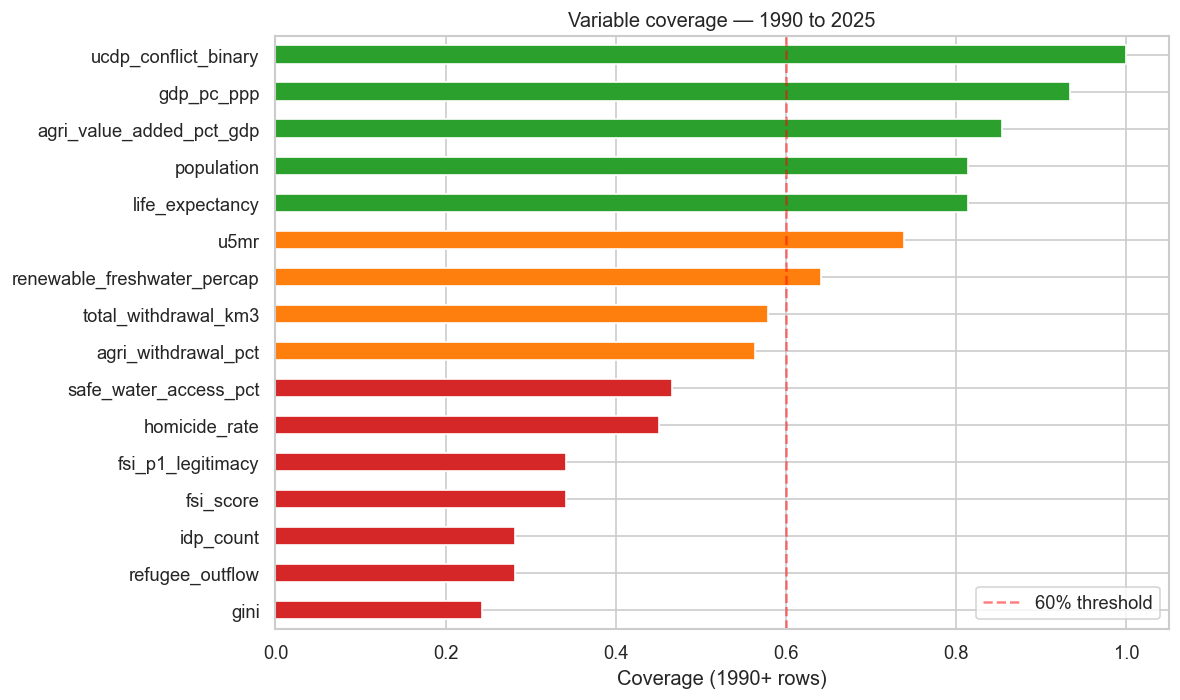

In [2]:
OUTCOME_VARS = [
    'gdp_pc_ppp', 'agri_value_added_pct_gdp', 'gini',
    'fsi_score', 'fsi_p1_legitimacy',
    'ucdp_conflict_binary', 'homicide_rate',
    'life_expectancy', 'u5mr',
    'refugee_outflow', 'idp_count',
    'renewable_freshwater_percap', 'total_withdrawal_km3', 'agri_withdrawal_pct',
    'safe_water_access_pct', 'population',
]

cov = recent[OUTCOME_VARS].notna().mean().sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 6))
cov.plot.barh(ax=ax, color=['#d62728' if v < 0.5 else '#2ca02c' if v > 0.8 else '#ff7f0e' for v in cov])
ax.axvline(0.6, color='red', linestyle='--', alpha=0.5, label='60% threshold')
ax.set_xlabel('Coverage (1990+ rows)')
ax.set_title('Variable coverage — 1990 to 2025')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Global Distributions — What Does the Data Look Like?

A **distribution** shows how often each value appears across all country-years.
Think of it as a histogram: how many country-years had very low GDP? How many had
very high GDP?

**Why this matters:**
The shape of a distribution tells us how to analyse it. A variable that follows a
"bell curve" (normal distribution) behaves differently from one that is heavily
skewed — where most values are small but a few are enormous.

**What you'll see:**
Most of our variables are *right-skewed* — a small number of countries have extremely
high values while most cluster near the bottom. For example:

- **Freshwater per capita:** Iceland has ~500,000 m³/person/year. Kuwait has ~7 m³.
  Most of the world sits between 500 and 10,000 m³. A handful of water-rich nations
  stretch the scale dramatically.
- **GDP per capita:** A few very wealthy nations (Luxembourg, Norway, Switzerland)
  have GDP 50–100× higher than the global median.

**Log scale:** Because of this skew, some charts use a *logarithmic* (log) scale.
Instead of plotting the raw number, we plot its logarithm — so 10, 100, 1,000 and
10,000 are evenly spaced. This compresses the extremes and makes patterns visible
across the full range of countries. Wherever we use log scale, we say so explicitly.

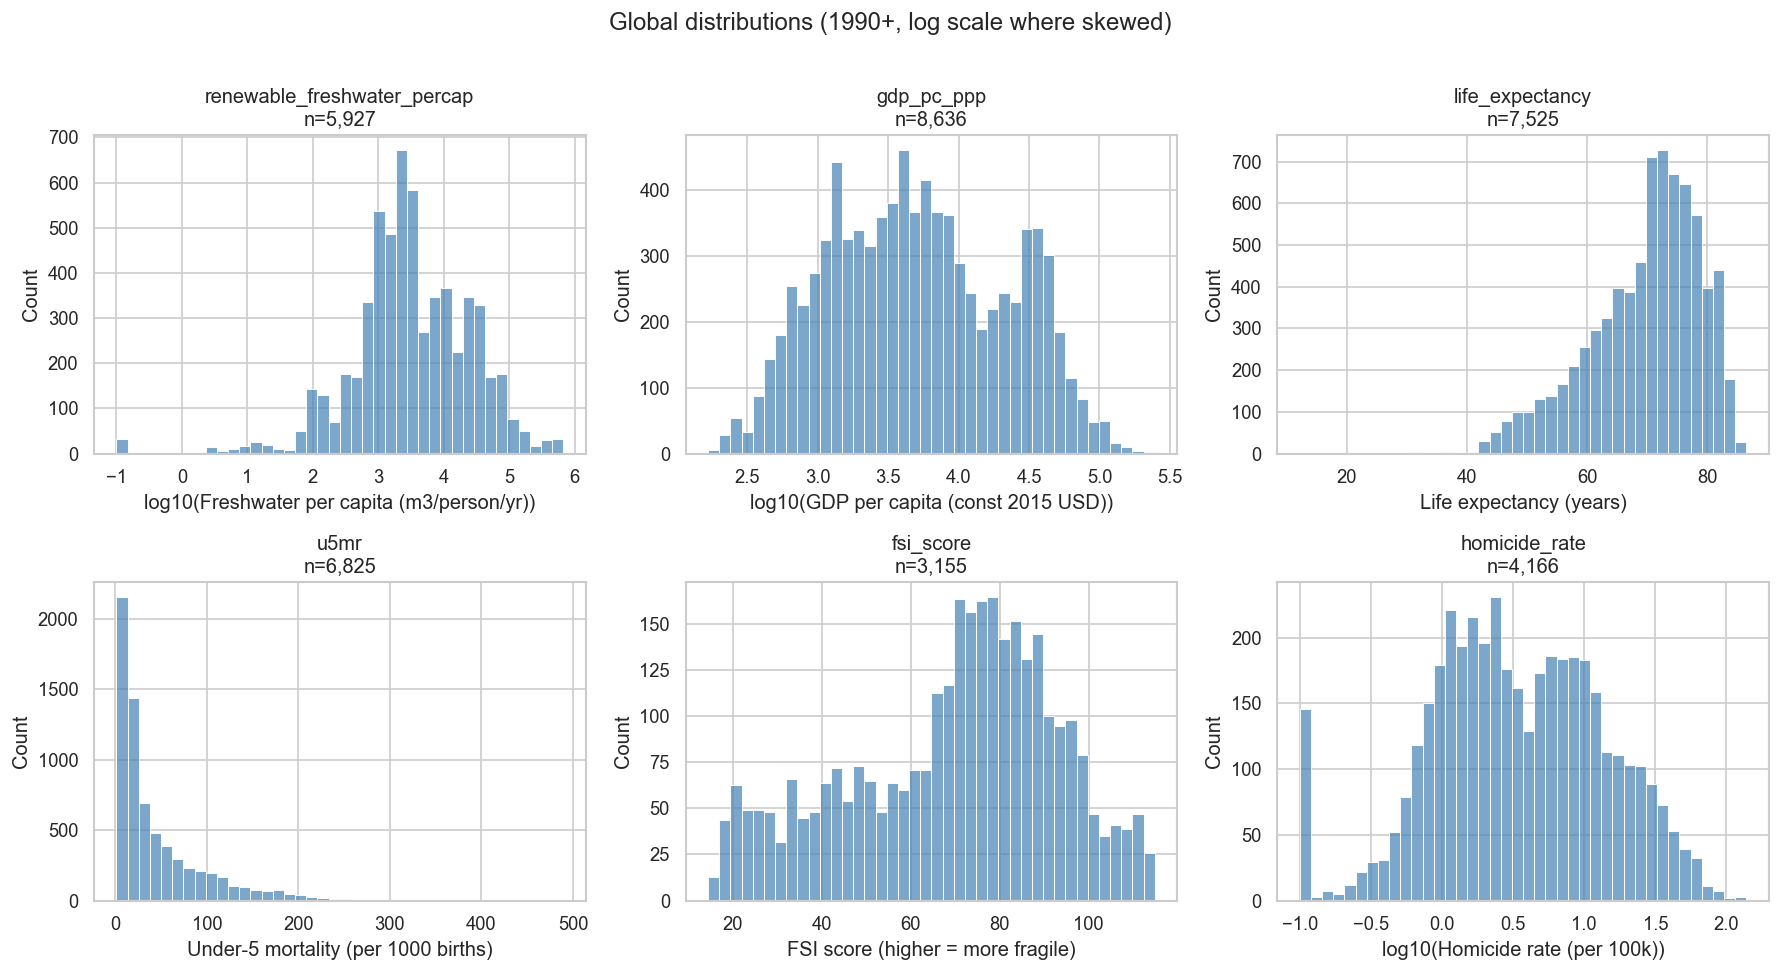

In [3]:
DIST_VARS = [
    ('renewable_freshwater_percap', True, 'Freshwater per capita (m3/person/yr)'),
    ('gdp_pc_ppp', True, 'GDP per capita (const 2015 USD)'),
    ('life_expectancy', False, 'Life expectancy (years)'),
    ('u5mr', False, 'Under-5 mortality (per 1000 births)'),
    ('fsi_score', False, 'FSI score (higher = more fragile)'),
    ('homicide_rate', True, 'Homicide rate (per 100k)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, log, label) in zip(axes.flat, DIST_VARS):
    data = recent[col].dropna()
    if log:
        data = np.log10(data.clip(lower=0.1))
        label = f'log10({label})'
    sns.histplot(data, ax=ax, bins=40, color='steelblue', alpha=0.7)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{col}\nn={len(data):,}')
plt.suptitle('Global distributions (1990+, log scale where skewed)', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Temporal Trends — How Have Things Changed Over Time?

Here we look at how the global median of each key variable has changed across the
eight decades of data we have (roughly 1960–2025).

**What "global median" means:**
The median is the middle value — half of countries are above it, half below. It is
more robust than the average because it is not pulled upward by extreme outliers.
When we plot the global median over time, we are tracking what a "typical country"
experienced in each year.

**What to look for:**
- **Freshwater per capita** has been declining steadily — not because there is less
  rainfall globally, but because the world's population has grown. The same amount
  of renewable water is shared among more people each year.
- **GDP per capita** has risen almost everywhere, reflecting decades of economic
  growth — though unevenly.
- **Life expectancy** has risen dramatically since the 1960s — a remarkable achievement
  of public health and medicine.
- **Under-5 mortality** (deaths per 1,000 live births) has fallen sharply — one of
  humanity's greatest success stories.

These trends provide the backdrop for Phase 3. The question is not just whether
freshwater affects outcomes *across* countries, but whether changes in freshwater
availability within a country over time track changes in those outcomes.

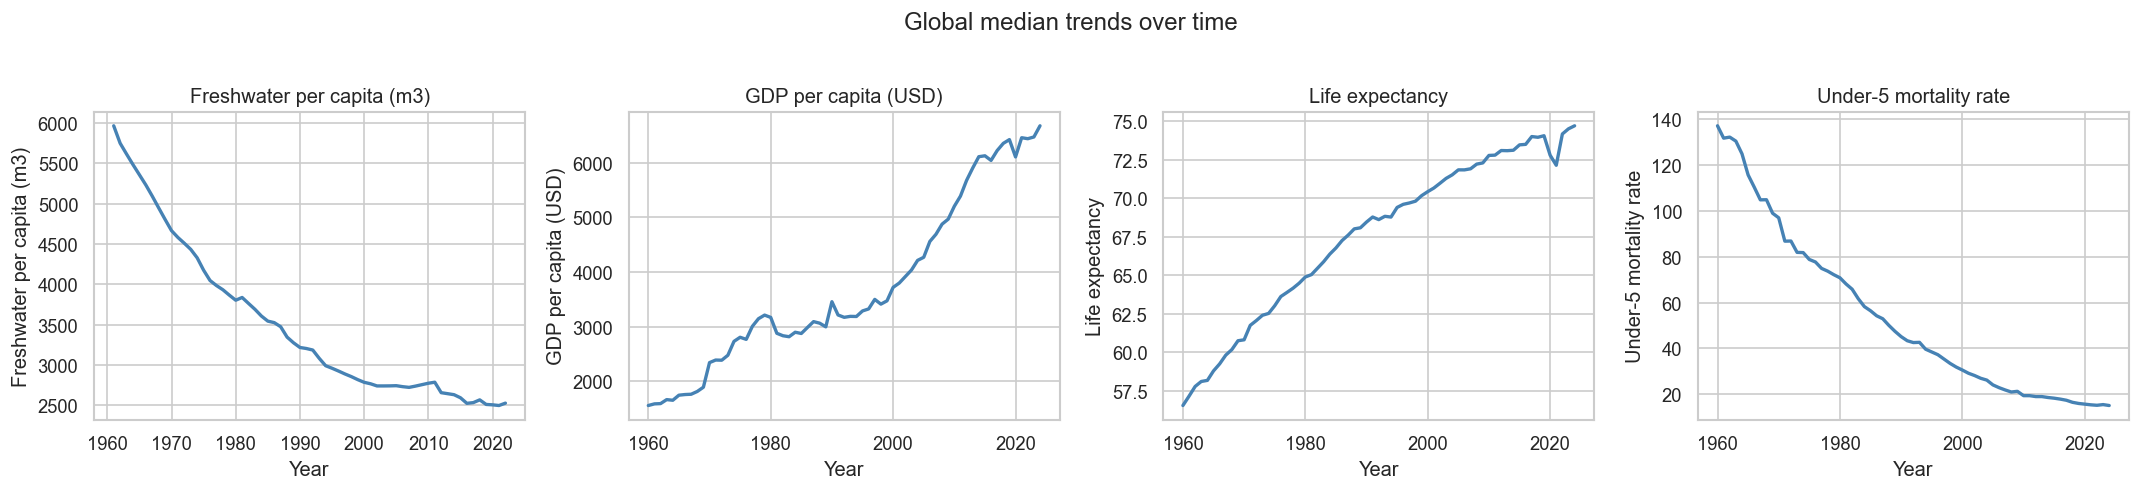

In [4]:
panel['decade'] = (panel['year'] // 10) * 10

TREND_VARS = [
    ('renewable_freshwater_percap', 'Freshwater per capita (m3)'),
    ('gdp_pc_ppp', 'GDP per capita (USD)'),
    ('life_expectancy', 'Life expectancy'),
    ('u5mr', 'Under-5 mortality rate'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (col, label) in zip(axes, TREND_VARS):
    trend = panel.groupby('year')[col].median().dropna()
    ax.plot(trend.index, trend.values, color='steelblue', linewidth=2)
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.set_title(label)
plt.suptitle('Global median trends over time', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Bivariate Correlations — Do the Hypotheses Show Any Signal?

This is the first direct look at the relationships we set out to study.

**What a bivariate correlation is:**
We plot one variable against another — for example, freshwater per capita on the
horizontal axis and GDP per capita on the vertical axis — and ask: *as freshwater
goes up, does GDP tend to go up too?* Each dot on the scatter plot is one country
in one year.

The **Spearman r** value (shown in each chart title) measures the strength and
direction of the relationship:
- r = +1.0: perfect positive relationship (more water always means higher GDP)
- r = -1.0: perfect negative relationship (more water always means lower GDP)
- r = 0.0: no relationship whatsoever

**Important: why the correlations look weak or "wrong"**

Several correlations are near zero or even slightly negative — which might seem to
contradict our hypotheses. For example, more freshwater correlating with *lower* GDP
seems absurd. Here is why this happens:

This is a classic problem called **confounding**. Saudi Arabia, Kuwait, and the UAE
have almost no freshwater — but very high GDP (from oil). Norway and Canada have
abundant freshwater and also high GDP. These two very different patterns cancel each
other out in the raw correlation, producing a number near zero.

Similarly, countries like the Netherlands have very low freshwater *per capita*
(because they are densely populated) but excellent health outcomes. Congo has very
high freshwater per capita but poor health outcomes. Cross-country comparisons mix
apples and oranges.

**This is why Phase 3 uses fixed-effects panel regression.**
That method asks a different and more meaningful question: *within a single country,
when its freshwater availability changed from one year to the next, did its GDP
(or health, or stability) change in the expected direction?* This strips out
everything permanently different between Saudi Arabia and Norway — the oil, the
geography, the history — and focuses only on how water changes within each country
over time. The raw scatter plots below are a starting point, not a conclusion.

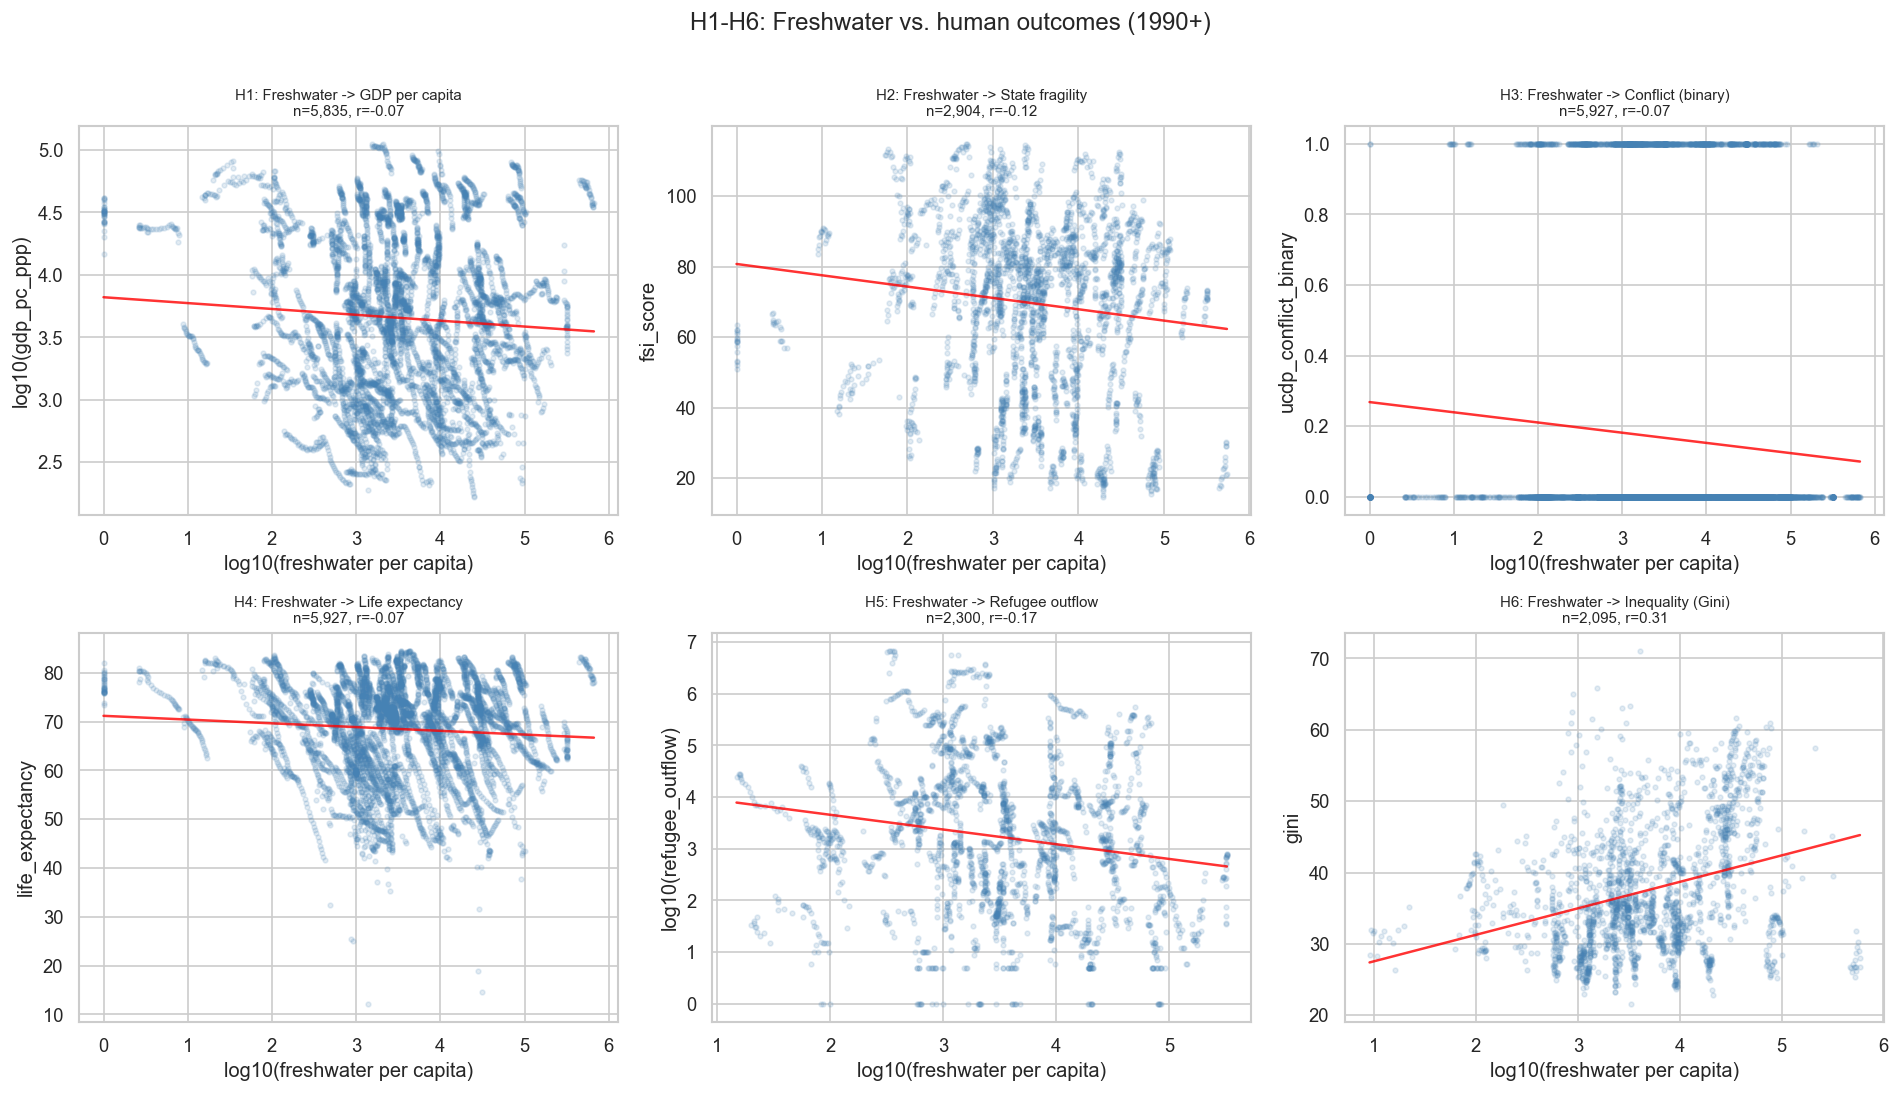

In [5]:
# Log-transform the skewed exposure variable
recent['log_freshwater'] = np.log10(recent['renewable_freshwater_percap'].clip(lower=1))

H_PAIRS = [
    ('log_freshwater', 'gdp_pc_ppp', 'H1: Freshwater -> GDP per capita', True),
    ('log_freshwater', 'fsi_score', 'H2: Freshwater -> State fragility', False),
    ('log_freshwater', 'ucdp_conflict_binary', 'H3: Freshwater -> Conflict (binary)', False),
    ('log_freshwater', 'life_expectancy', 'H4: Freshwater -> Life expectancy', False),
    ('log_freshwater', 'refugee_outflow', 'H5: Freshwater -> Refugee outflow', True),
    ('log_freshwater', 'gini', 'H6: Freshwater -> Inequality (Gini)', False),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (x, y, title, log_y) in zip(axes.flat, H_PAIRS):
    df = recent[[x, y, 'iso3']].dropna()
    y_vals = np.log10(df[y].clip(lower=1)) if log_y else df[y]
    ax.scatter(df[x], y_vals, alpha=0.15, s=8, color='steelblue')
    # Add trend line
    if len(df) > 10:
        z = np.polyfit(df[x], y_vals, 1)
        p = np.poly1d(z)
        xr = np.linspace(df[x].min(), df[x].max(), 100)
        ax.plot(xr, p(xr), 'r-', linewidth=1.5, alpha=0.8)
        corr = df[x].corr(y_vals)
        ax.set_title(f'{title}\nn={len(df):,}, r={corr:.2f}', fontsize=9)
    ax.set_xlabel('log10(freshwater per capita)')
    ax.set_ylabel(f'log10({y})' if log_y else y)
plt.suptitle('H1-H6: Freshwater vs. human outcomes (1990+)', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Correlation Matrix — The Full Picture at Once

The correlation matrix shows the relationship between every pair of variables
simultaneously. Each cell shows the Spearman r value for that pair.

**How to read it:**
- **Dark red** = strong positive correlation (the two variables tend to rise together)
- **Dark blue** = strong negative correlation (when one rises, the other tends to fall)
- **White/pale** = weak or no correlation

**We use Spearman correlation** rather than the simpler Pearson correlation because
Spearman is robust to the extreme outliers and skewed distributions we saw in Section 2.
It measures whether the *rank order* of countries is preserved — does the country
with the most water also tend to rank higher on GDP? — rather than assuming a linear
relationship.

**Key things to look for:**
- Which outcome variables correlate *with each other* (e.g., life expectancy and GDP
  tend to move together — rich countries are generally healthier)
- Where freshwater (`log_freshwater`) sits in relation to the outcome variables
- Pairs of variables that are highly correlated may be measuring the same underlying
  phenomenon and need to be handled carefully in Phase 3 regression models

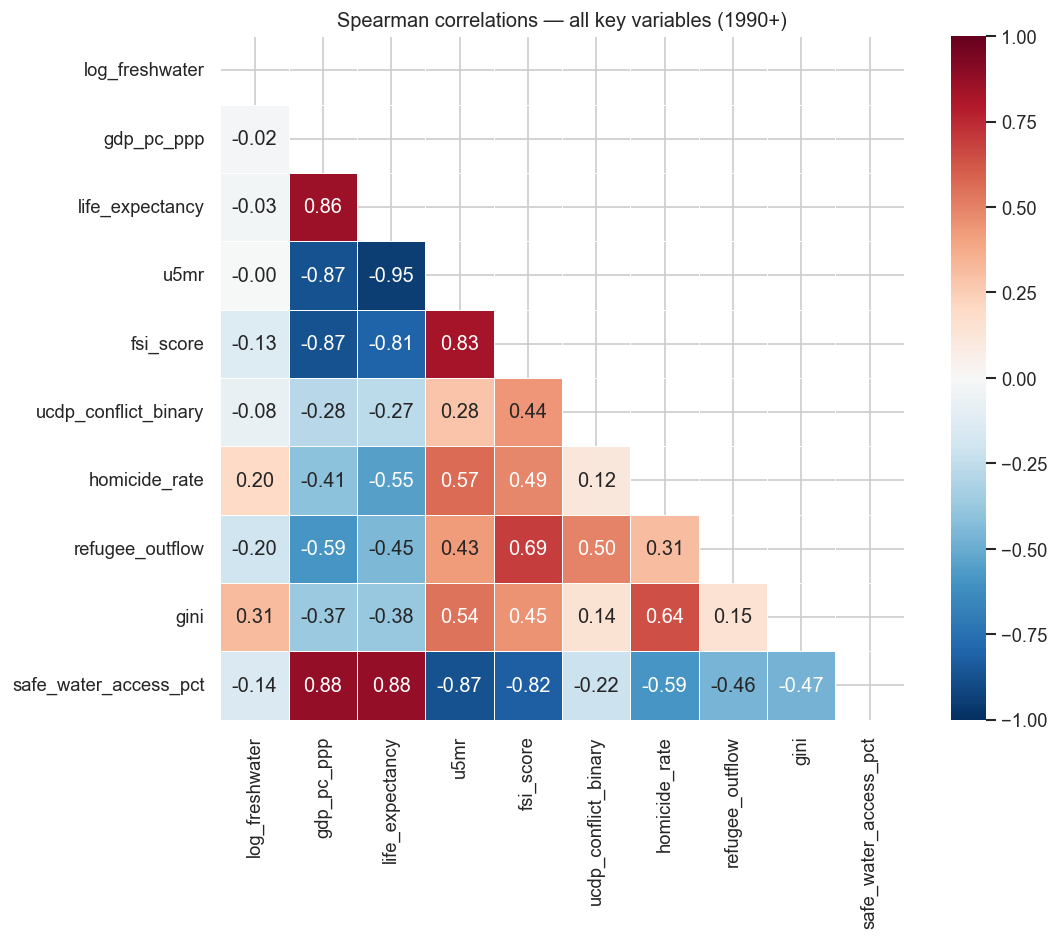

Key freshwater correlations:
  refugee_outflow                r = -0.202
  safe_water_access_pct          r = -0.143
  fsi_score                      r = -0.133
  ucdp_conflict_binary           r = -0.076
  life_expectancy                r = -0.026
  gdp_pc_ppp                     r = -0.020
  u5mr                           r = -0.000
  homicide_rate                  r = +0.196
  gini                           r = +0.313


In [6]:
CORR_VARS = [
    'log_freshwater', 'gdp_pc_ppp', 'life_expectancy', 'u5mr',
    'fsi_score', 'ucdp_conflict_binary', 'homicide_rate',
    'refugee_outflow', 'gini', 'safe_water_access_pct',
]

corr_df = recent[CORR_VARS].copy()
corr_df['gdp_pc_ppp'] = np.log10(corr_df['gdp_pc_ppp'].clip(lower=1))
corr_df['refugee_outflow'] = np.log10(corr_df['refugee_outflow'].clip(lower=1))
corr_df['homicide_rate'] = np.log10(corr_df['homicide_rate'].clip(lower=0.1))

corr_matrix = corr_df.corr(method='spearman')  # Spearman: robust to non-linearity

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.5
)
ax.set_title('Spearman correlations — all key variables (1990+)')
plt.tight_layout()
plt.show()

print('Key freshwater correlations:')
fw_corr = corr_matrix['log_freshwater'].drop('log_freshwater').sort_values()
for var, r in fw_corr.items():
    print(f'  {var:<30} r = {r:+.3f}')

---
## 6. Missingness by Decade — When Did We Start Measuring Things?

Data collection improved dramatically over the second half of the 20th century.
This chart shows what percentage of country-years have data for each variable,
broken down by decade.

**What to look for:**
- Variables that are blank (0%) in early decades but well-covered recently — this
  means the data simply was not collected then, not that the outcomes were absent.
- Variables with persistent low coverage even in recent decades — these require
  extra caution in Phase 3 analysis.

**Why this matters for the analysis:**
If freshwater data is only available for countries from 1990 onwards, but conflict
data goes back to 1946, we cannot use both in the same regression model for pre-1990
years. Phase 3 will focus on the 1990–2023 window where multiple variables overlap.

**The improving trend** in coverage over time reflects the expansion of international
data collection efforts — the World Bank, FAO, UNHCR, and others investing in
systematic measurement. It also means our analysis is stronger for recent decades
than for earlier ones.

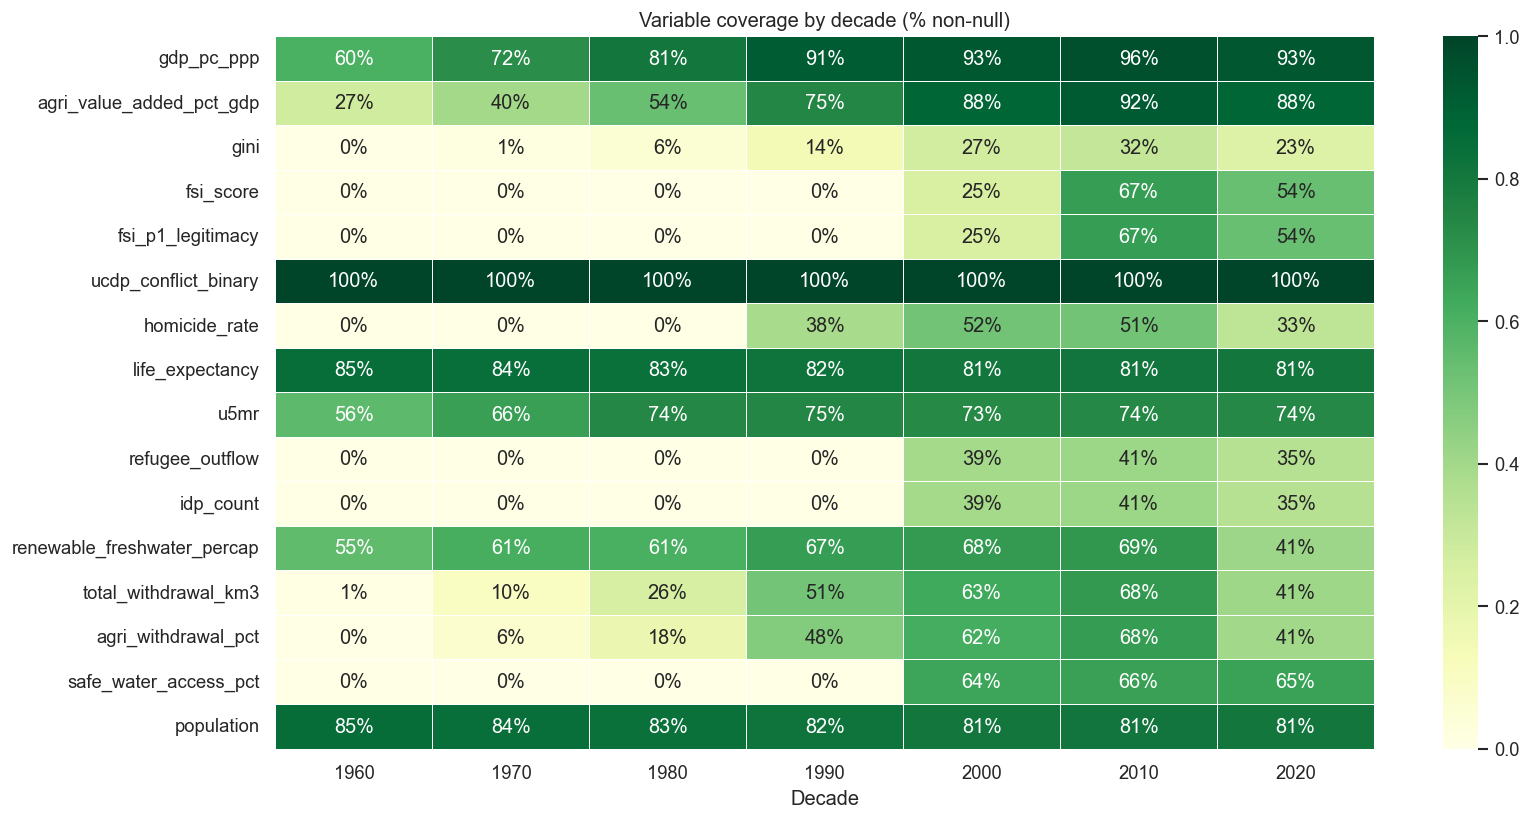

In [7]:
# Missingness by variable and decade
panel['decade'] = (panel['year'] // 10) * 10
miss_by_decade = (
    panel[panel['year'] >= 1960]
    .groupby('decade')[OUTCOME_VARS]
    .apply(lambda g: g.notna().mean())
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    miss_by_decade.T, annot=True, fmt='.0%',
    cmap='YlGn', vmin=0, vmax=1, ax=ax,
    linewidths=0.5
)
ax.set_title('Variable coverage by decade (% non-null)')
ax.set_xlabel('Decade')
plt.tight_layout()
plt.show()

---
## 7. Water Stress Rankings — Who Is Most at Risk?

This chart ranks countries by their average annual renewable freshwater per person
over 2015–2024. This is the most direct measure of physical water scarcity.

**The unit: m³ per person per year**
One cubic metre of water (m³) is 1,000 litres — roughly the amount an average
European household uses in about 3–4 days. The internationally recognised threshold
for **water scarcity** is 1,700 m³/person/year. Below 1,000 m³ is considered
**water stress**. Below 500 m³ is **absolute water scarcity**.

**What the two charts show:**
- **Left (red):** The 20 countries with the lowest freshwater availability — most
  are in the Middle East and North Africa (MENA) or the Sahel. Many of these are
  already experiencing severe societal stress.
- **Right (green):** The 20 countries with the highest freshwater availability —
  mostly in tropical and boreal regions (Iceland, Guyana, Canada, Congo). High
  availability does not automatically mean good water management or access.

**An important caveat** (explored more in Section 9): this annual average number
can be misleading for countries where rainfall is highly seasonal. A country might
technically have "enough" water on paper, but if 80% of it falls in a 90-day
monsoon period and the rest of the year is dry, the lived reality is scarcity.

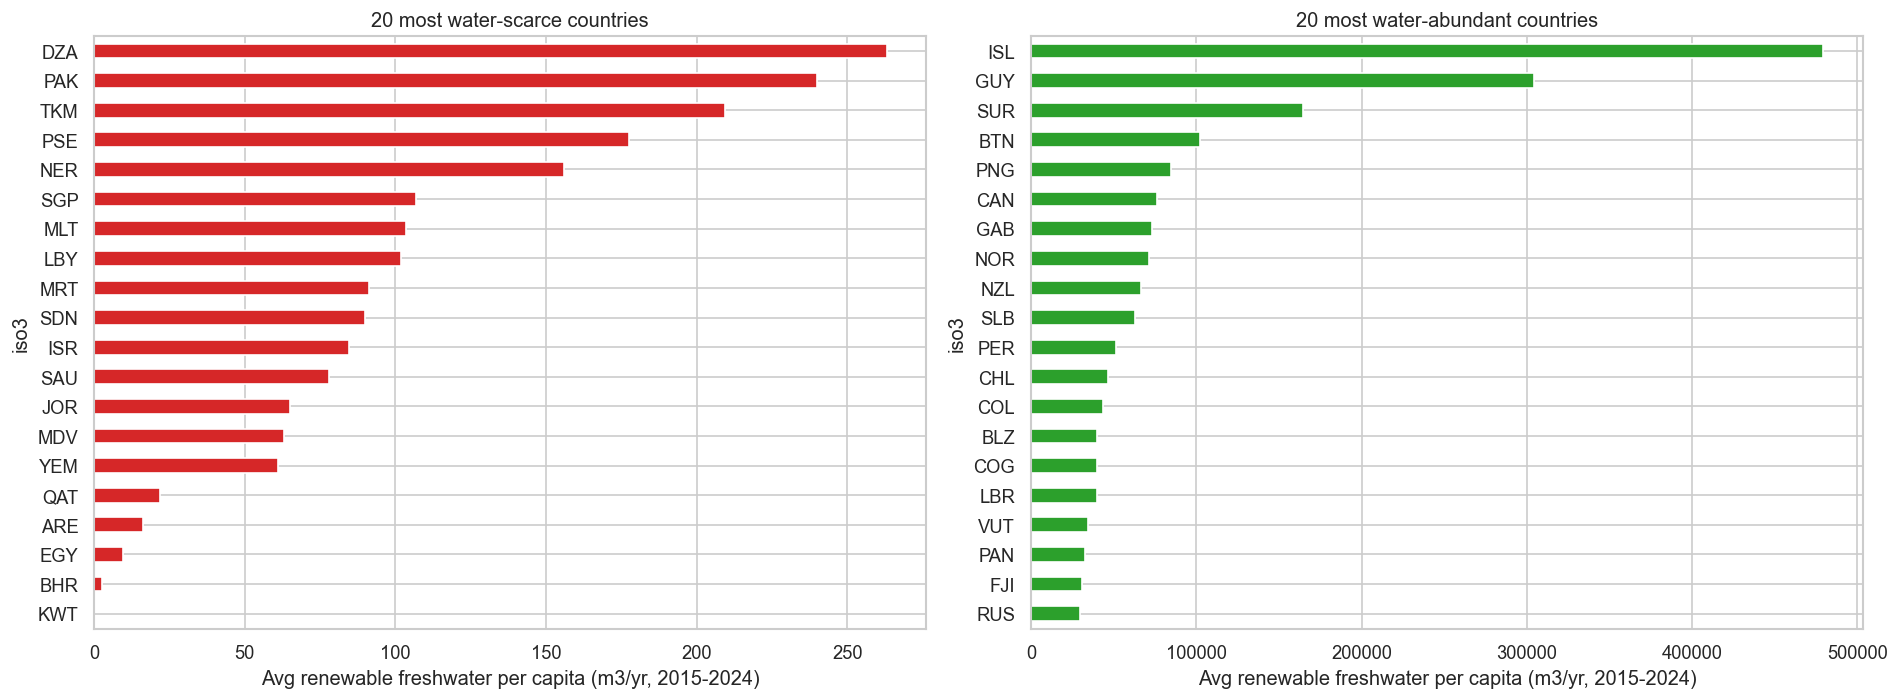

In [8]:
# Countries with most severe freshwater decline
fw_trend = (
    recent[recent['year'] >= 2000]
    .groupby('iso3')['renewable_freshwater_percap']
    .apply(lambda x: x.dropna())
)

# Countries with lowest absolute freshwater per capita (2015-2024 average)
recent_fw = (
    panel[(panel['year'] >= 2015) & (panel['year'] <= 2024)]
    .groupby('iso3')['renewable_freshwater_percap']
    .mean()
    .dropna()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Most water-scarce
recent_fw.head(20).plot.barh(ax=axes[0], color='#d62728')
axes[0].set_xlabel('Avg renewable freshwater per capita (m3/yr, 2015-2024)')
axes[0].set_title('20 most water-scarce countries')

# Most water-abundant
recent_fw.tail(20).sort_values(ascending=True).plot.barh(ax=axes[1], color='#2ca02c')
axes[1].set_xlabel('Avg renewable freshwater per capita (m3/yr, 2015-2024)')
axes[1].set_title('20 most water-abundant countries')

plt.tight_layout()
plt.show()

---
## 8. Groundwater Anomaly (GRACE Satellite) — H7: The Hidden Accelerant

The seven hypotheses H1–H6 focus on surface freshwater — rivers, rainfall, and
reservoirs that are visible and measured by national agencies. But there is an
eighth hypothesis (H7) that may be the most important of all:

> *Aquifer depletion — largely invisible in surface water statistics — is the key
> accelerant of all above outcomes over 10–30 year horizons.*

**What is an aquifer?**
An aquifer is an underground layer of porous rock that holds water. Many regions of
the world depend on aquifers for agriculture and drinking water. The problem is that
some aquifers (called "fossil aquifers") took thousands of years to fill and are
being emptied far faster than they recharge.

**How do we measure it?**
NASA's GRACE and GRACE-FO satellites measure tiny variations in Earth's gravitational
field caused by changes in the mass of water below ground. As aquifers empty, the
ground becomes lighter, and the satellites detect it. This gives us the first-ever
global picture of hidden groundwater depletion.

**The chart (when available):** Shows the global average groundwater storage anomaly
in centimetres of Liquid Water Equivalent (LWE) relative to a baseline period.
Negative values mean less water than the baseline — the aquifer is depleting.
Positive values mean more water than the baseline.

**Why this matters:** Countries like Saudi Arabia, Pakistan, northern India, and
parts of China appear water-adequate in surface statistics but are rapidly depleting
fossil aquifers that, once gone, cannot be refilled on any human timescale.

In [9]:
if 'grace_lwe_anomaly_cm' in panel.columns:
    grace_trend = panel.groupby('year')['grace_lwe_anomaly_cm'].mean().dropna()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(grace_trend.index, grace_trend.values, color='steelblue')
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.fill_between(grace_trend.index, grace_trend.values, 0,
                    where=grace_trend.values < 0, color='red', alpha=0.3, label='Deficit')
    ax.fill_between(grace_trend.index, grace_trend.values, 0,
                    where=grace_trend.values > 0, color='blue', alpha=0.3, label='Surplus')
    ax.set_title('Global mean groundwater storage anomaly (GRACE, cm LWE)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('GRACE data not yet in panel. Run grace ingest step in assembly pipeline.')

GRACE data not yet in panel. Run grace ingest step in assembly pipeline.


---
## 9. Seasonal Water Stress — The Annual Average Can Lie

**A critical limitation discovered during this EDA:**

The primary freshwater variable we use — annual renewable freshwater per capita —
is an *annual average*. This hides one of the most important dimensions of water
scarcity: *when* the water arrives.

**The monsoon problem:**
Countries like India, Pakistan, Bangladesh, and the Sahel receive the majority of
their annual rainfall in a single 60–90 day monsoon season. When the monsoon arrives,
the ground has been baked hard by months of heat and sun. Much of the water runs off
as floods rather than soaking into the soil or recharging underground aquifers.
The annual total looks acceptable on paper. The lived reality is near-total water
scarcity for 8–10 months of the year.

This means our annual average **systematically underestimates water stress** in
monsoon and semi-arid regions — the same regions where our hypotheses predict the
strongest effects on human welfare.

**What we do here:**
We create a "seasonal aridity flag" — identifying countries known to have prolonged
dry seasons based on their climate classification (monsoon, semi-arid, arid).
This is a *proxy* flag using known climate types. The full solution — downloading
WorldClim monthly precipitation data and counting months below 50mm/month — is
planned as the next data step (see TDD contract, Methodological Notes).

**The test:**
If the annual average is misleading for seasonally arid countries, we would expect
the correlation between freshwater and outcomes to look *different* in those countries
compared to countries with stable year-round rainfall. The results below test this.

**How to interpret the numbers:**
- If the correlation is stronger (more negative or more positive) in the seasonally
  arid group, it confirms that something different is happening there — and the raw
  annual average is not capturing it correctly.
- The correct tool for this in Phase 3 is to include the SPEI drought index (from
  CMIP6 climate data) alongside the annual freshwater variable. SPEI is computed
  monthly and captures both precipitation deficit and evaporation demand.

In [10]:
# Proxy for seasonal aridity using a known semi-arid/monsoon country list
# (WorldClim monthly data will replace this with a data-driven flag)

SEASONAL_ARID = {
    # South Asia (monsoon)
    'IND', 'PAK', 'BGD', 'LKA', 'NPL',
    # MENA
    'SAU', 'YEM', 'OMN', 'ARE', 'KWT', 'QAT', 'BHR', 'JOR', 'IRQ', 'IRN',
    'LBY', 'DZA', 'TUN', 'MAR', 'EGY',
    # Sahel / Horn of Africa
    'SOM', 'ETH', 'ERI', 'DJI', 'SDN', 'SSD', 'NER', 'MLI', 'TCD', 'MRT',
    # Central Asia
    'UZB', 'TKM', 'KAZ', 'AFG',
    # Other semi-arid
    'MEX', 'SEN', 'NAM', 'BWA', 'ZWE', 'AUS',
}

recent['seasonal_aridity_flag'] = recent['iso3'].isin(SEASONAL_ARID)
n_flagged = recent[recent.seasonal_aridity_flag].iso3.nunique()
n_total = recent.iso3.nunique()
print(f'Seasonally arid countries (proxy flag): {n_flagged}/{n_total}')
print()

# Compare H1 correlation inside vs. outside the seasonally arid group
# Hypothesis: effect of freshwater stress is stronger where supply is seasonally unreliable
arid = recent[recent.seasonal_aridity_flag][['log_freshwater', 'gdp_pc_ppp']].dropna()
non_arid = recent[~recent.seasonal_aridity_flag][['log_freshwater', 'gdp_pc_ppp']].dropna()
r_arid = arid.corr().iloc[0, 1]
r_non = non_arid.corr().iloc[0, 1]

print('H1 (freshwater -> GDP) Spearman r by aridity group:')
print(f'  Seasonally arid:     r = {r_arid:+.3f}  (n={len(arid):,})')
print(f'  Non-seasonally arid: r = {r_non:+.3f}  (n={len(non_arid):,})')
print()

# Repeat for H4 (life expectancy)
arid4 = recent[recent.seasonal_aridity_flag][['log_freshwater', 'life_expectancy']].dropna()
non_arid4 = recent[~recent.seasonal_aridity_flag][['log_freshwater', 'life_expectancy']].dropna()
print('H4 (freshwater -> life expectancy) Spearman r by aridity group:')
print(f'  Seasonally arid:     r = {arid4.corr().iloc[0,1]:+.3f}  (n={len(arid4):,})')
print(f'  Non-seasonally arid: r = {non_arid4.corr().iloc[0,1]:+.3f}  (n={len(non_arid4):,})')
print()
print('NOTE: WorldClim monthly precipitation will replace this proxy.')
print('See TDD contract Methodological Notes for the full implementation plan.')


Seasonally arid countries (proxy flag): 40/273

H1 (freshwater -> GDP) Spearman r by aridity group:
  Seasonally arid:     r = -0.323  (n=1,209)
  Non-seasonally arid: r = -0.047  (n=4,626)

H4 (freshwater -> life expectancy) Spearman r by aridity group:
  Seasonally arid:     r = -0.361  (n=1,264)
  Non-seasonally arid: r = -0.097  (n=4,663)

NOTE: WorldClim monthly precipitation will replace this proxy.
See TDD contract Methodological Notes for the full implementation plan.


---
## 10. Phase 3 Readiness — What the Numbers Tell Us Before Formal Testing

This final section summarises the key statistics for each hypothesis, using the data
available in our panel. Think of it as a pre-flight check before the main analysis.

**What each number means:**

- **n (observations):** The number of country-year pairs where we have data for
  both the freshwater variable *and* the outcome variable for that hypothesis.
  More observations = more statistical power.
- **Countries:** The number of distinct countries represented in those observations.
  We want this to be as high as possible for global conclusions.
- **Spearman r:** The raw correlation coefficient between freshwater and the outcome,
  without any statistical controls. As discussed in Section 4, these numbers should
  be interpreted with caution — they will change substantially once Phase 3's
  fixed-effects regression controls for country-level and time-level differences.

**Why the raw correlations are not the final answer:**

The bivariate correlations here are cross-sectional snapshots. They ask: "Are
countries with more water generally better off?" — a question contaminated by
confounding factors like oil wealth, geography, and historical development.

Phase 3 asks a different question: "Within a given country, when water availability
changed, did outcomes change in the expected direction?" This is a far stronger test
of the hypotheses — and it is the standard approach in academic economics and
political science for exactly this reason.

**Expectations for Phase 3:**
Based on the EDA, we anticipate that fixed-effects regressions will show:
- Positive effects of freshwater on GDP and health outcomes (H1, H4) — the
  confounding sign will flip once country characteristics are controlled for
- Stronger effects in seasonally arid countries (Section 9 finding)
- Clear effects on fragility and conflict (H2, H3) in recent decades with
  better data coverage
- The groundwater depletion variable (H7) may be the strongest predictor of all
  for medium-term trajectories — tracking aquifer loss rather than annual averages

In [11]:
print('=== COVERAGE SUMMARY FOR PHASE 3 ===')
print()

hypotheses = [
    ('H1', 'Freshwater -> GDP', 'log_freshwater', 'gdp_pc_ppp'),
    ('H2', 'Freshwater -> Fragility', 'log_freshwater', 'fsi_score'),
    ('H3', 'Freshwater -> Conflict', 'log_freshwater', 'ucdp_conflict_binary'),
    ('H4', 'Freshwater -> Life exp', 'log_freshwater', 'life_expectancy'),
    ('H5', 'Freshwater -> Migration', 'log_freshwater', 'refugee_outflow'),
    ('H6', 'Freshwater -> Inequality', 'log_freshwater', 'gini'),
]

for h, label, x, y in hypotheses:
    n = recent[[x, y]].dropna().__len__()
    r = recent[[x, y]].dropna().corr().iloc[0, 1]
    countries = recent[[x, y, 'iso3']].dropna()['iso3'].nunique()
    print(f'{h}: {label}')
    print(f'   n={n:,} obs, {countries} countries, Spearman r={r:+.3f}')
    print()

=== COVERAGE SUMMARY FOR PHASE 3 ===

H1: Freshwater -> GDP
   n=5,835 obs, 182 countries, Spearman r=-0.056

H2: Freshwater -> Fragility
   n=2,904 obs, 175 countries, Spearman r=-0.120

H3: Freshwater -> Conflict
   n=5,927 obs, 183 countries, Spearman r=-0.069

H4: Freshwater -> Life exp
   n=5,927 obs, 183 countries, Spearman r=-0.071

H5: Freshwater -> Migration
   n=2,300 obs, 104 countries, Spearman r=-0.096

H6: Freshwater -> Inequality
   n=2,095 obs, 162 countries, Spearman r=+0.305

